<u><b><h1 style="text-align:center; line-height:25px; color:#000000; background:#EFEFEF; border: 1px solid #FF6B6B ; padding:20px;">Sentiment analysis of customer reviews</h1></b></u>
**Course:** (DLBDSEAIS – Project: Artificial Intelligence  
**Tools**: Pandas, scikit-learn for the TF-IDF baseline, Hugging Face transformers (with PyTorch) for DistilBERT and Gradio for the interface  
**Dataset:** <a href="https://www.kaggle.com/datasets/fawadhossaini1415/amazon-fashion-800k-user-reviews-dataset">Amazon Fashion Products Reviews</a>  
**<a href="https://github.com/davidlupau/sentiment-analysis-customer-reviews">GitHub repository</a>**

<b><h2 style="padding: 10px; border-left: 3px solid #FF6B6B;">Setup & Imports</h2></b>

In [1]:
# Core
import re
import time
import platform
from pathlib import Path

import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
)

print("Import successful")

/opt/anaconda3/envs/thesis/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Import successful


### Select device
Select the compute backend automatically so the notebook runs unchanged on a cloud GPU (CUDA), an Apple Silicon Mac (MPS), or any CPU-only machine.

In [2]:
def detect_device() -> torch.device:
    """Detect the best available compute device.

    Checks hardware availability in order of preference:
      1. CUDA  – NVIDIA GPU (fastest for most deep-learning workloads).
      2. MPS   – Apple Silicon GPU (Metal Performance Shaders).
      3. CPU   – universal fallback.

    Returns:
        torch.device: The most capable device available on this machine.
    """
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = detect_device()
RANDOM_STATE = 42
SAMPLES_PER_CLASS = 5_000
TFIDF_MAX_FEATURES = 10_000
TFIDF_NGRAM_RANGE = (1, 2)

# DistilBERT champion
DISTILBERT_MODEL = "distilbert-base-uncased"
NUM_EPOCHS = 3
MAX_TOKEN_LENGTH = 256
BATCH_SIZE = 16
LABEL_TO_ID = {"negative": 0, "neutral": 1, "positive": 2}
ID_TO_LABEL = {0: "negative", 1: "neutral", 2: "positive"}

# DistilBERT model persistence
MODEL_SAVE_DIR = "saved_model"

print(f"Device            : {DEVICE}")
print(f"Platform          : {platform.platform()}")
print(f"PyTorch           : {torch.__version__}")
print(f"Random state      : {RANDOM_STATE}")
print(f"Samples per class : {SAMPLES_PER_CLASS:,}")
print(f"TF-IDF features   : {TFIDF_MAX_FEATURES:,}")
print(f"TF-IDF n-grams    : {TFIDF_NGRAM_RANGE}")
print(f"DistilBERT model  : {DISTILBERT_MODEL}")
print(f"Epochs            : {NUM_EPOCHS}")
print(f"Max token length  : {MAX_TOKEN_LENGTH}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Model save dir    : {MODEL_SAVE_DIR}")

Device            : mps
Platform          : macOS-26.5.1-arm64-arm-64bit-Mach-O
PyTorch           : 2.12.0
Random state      : 42
Samples per class : 5,000
TF-IDF features   : 10,000
TF-IDF n-grams    : (1, 2)
DistilBERT model  : distilbert-base-uncased
Epochs            : 3
Max token length  : 256
Batch size        : 16
Model save dir    : saved_model


### Loading the dataset

In [3]:
PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "data").is_dir()
)

df = pd.read_csv(PROJECT_ROOT / "data" / "amazon-fashion-reviews-dataset.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


### Data cleaning

In [4]:
def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """Remove unusable rows from the dataset.

    Drops rows where 'text' or 'rating' contain null values, then removes
    exact duplicate rows. Reports counts at each step.

    Args:
        df: Raw DataFrame loaded from the CSV file.

    Returns:
        pd.DataFrame: Cleaned DataFrame with nulls and duplicates removed.
    """
    initial_rows = len(df)
    print(f"Initial row count: {initial_rows:,}")

    null_mask = df[["text", "rating"]].isnull().any(axis=1)
    null_count = int(null_mask.sum())
    if null_count:
        print(f"Dropping {null_count:,} rows with null values in 'text' or 'rating'.")
        df = df[~null_mask]
    else:
        print("No null values found in 'text' or 'rating'.")

    duplicate_count = int(df.duplicated().sum())
    if duplicate_count:
        print(f"Dropping {duplicate_count:,} duplicate rows.")
        df = df.drop_duplicates()
    else:
        print("No duplicate rows found.")

    cleaned_rows = len(df)
    print(f"Final row count: {cleaned_rows:,} ({initial_rows - cleaned_rows:,} rows removed).\n")

    return df.reset_index(drop=True)


df = clean_dataset(df)

Initial row count: 867,310
Dropping 298 rows with null values in 'text' or 'rating'.
Dropping 5,264 duplicate rows.
Final row count: 861,748 (5,562 rows removed).



### Rating to sentiment mapping

In [5]:
def map_rating_to_sentiment(df: pd.DataFrame) -> pd.DataFrame:
    """Add a 'sentiment' column derived from the 'rating' column.

    Mapping:
        1, 2  → negative
        3     → neutral
        4, 5  → positive
    """
    mapping = {1: "negative", 2: "negative", 3: "neutral", 4: "positive", 5: "positive"}
    df = df.copy()
    df["sentiment"] = df["rating"].map(mapping)
    counts = df["sentiment"].value_counts()
    print("Sentiment distribution:")
    for label in ["positive", "neutral", "negative"]:
        print(f"  {label}: {counts.get(label, 0):,}")
    print()
    return df


df = map_rating_to_sentiment(df)
df.head()

Sentiment distribution:
  positive: 345,569
  neutral: 172,247
  negative: 343,932



,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchases,target,sentiment
0,1.0,It say 5 pair when purchasing but only get 2 r...,I was looking for 5 pair and only received 2 p...,[],B07QFTMTLP,B07QFTMTLP,AHASEZ65RESN57BMGRV6QBM5DTIA,1565088068852,0,True,-1,negative
1,1.0,DonÃ¢ÂÂt do it!,Just donÃ¢ÂÂt. These things fell apart after...,[],B0764KKDN1,B0764KKDN1,AE3AMA3QSOHFKV46JJAHTHMMIR6A,1622416429592,0,True,-1,negative
2,1.0,Small,Retuned is too small for me,[],B07J1WHVCP,B07J1WHVCP,AH4CFWQE2HTC5BSWIEF3LVLUFK6A,1565284666220,0,True,-1,negative
3,1.0,Pre-Used When Received,This product came with the sleeves turned insi...,[],B0773JWP64,B0773JWP64,AFEKQFJWST6MVTKEJBQKUUBTWK7A,1581963636172,0,False,-1,negative
4,1.0,Worn once and several places at seams have com...,Worn once and several places at seams have com...,[],B099NST9RX,B08JGNS1NK,AGU2FPKN6ARXUSSGBT6WTVLZKJSQ,1640895438476,0,True,-1,negative


### Class imbalance

Plot saved to /Users/davidlupau/Documents/Filen/_IU/5th semester/30. Artificial Intelligence Project/sentiment-analysis-customer-reviews/analysis_output/class_imbalance.png


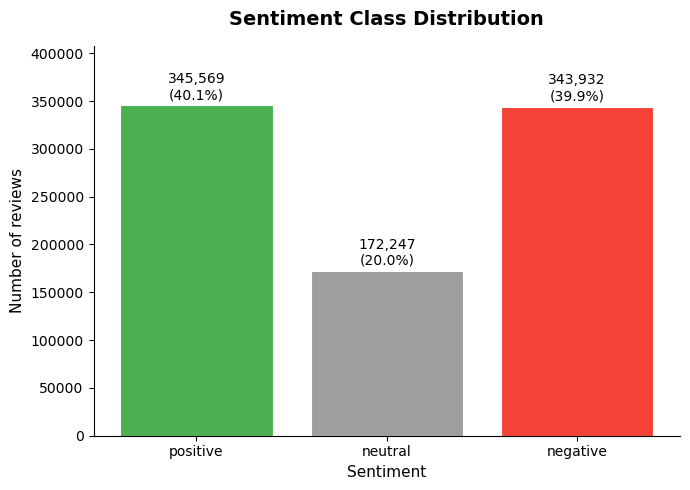

In [6]:
def plot_class_imbalance(df):
    counts = df["sentiment"].value_counts().reindex(["positive", "neutral", "negative"])
    total = counts.sum()

    fig, ax = plt.subplots(figsize=(7, 5))
    colors = ["#4CAF50", "#9E9E9E", "#F44336"]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.8)

    for bar, count in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.004,
            f"{count:,}\n({count / total * 100:.1f}%)",
            ha="center", va="bottom", fontsize=10,
        )

    ax.set_title("Sentiment Class Distribution", fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Sentiment", fontsize=11)
    ax.set_ylabel("Number of reviews", fontsize=11)
    ax.set_ylim(0, counts.max() * 1.18)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()

    output_dir = PROJECT_ROOT / "analysis_output"
    output_dir.mkdir(exist_ok=True)
    output_path = output_dir / "class_imbalance.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"Plot saved to {output_path}")
    plt.show()


plot_class_imbalance(df)

### Train / test split

In [7]:
def split_dataset(
    df: pd.DataFrame,
    test_size: float = 0.2,
    random_state: int = 42,
) -> tuple:
    print(f"Splitting dataset — test size: {test_size:.0%}, random_state: {random_state}")
    df_train, df_test = train_test_split(
        df, test_size=test_size, random_state=random_state, stratify=df["sentiment"]
    )
    df_train = df_train.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    print(f"  Train : {len(df_train):,} rows")
    print(f"  Test  : {len(df_test):,} rows")
    print("Test set distribution (realistic, kept imbalanced):")
    test_counts = df_test["sentiment"].value_counts()
    total_test = len(df_test)
    for cls in ["positive", "neutral", "negative"]:
        n = test_counts.get(cls, 0)
        print(f"  {cls}: {n:,} ({n / total_test * 100:.1f}%)")
    print()
    return df_train, df_test


df_train, df_test = split_dataset(df)

Splitting dataset — test size: 20%, random_state: 42
  Train : 689,398 rows
  Test  : 172,350 rows
Test set distribution (realistic, kept imbalanced):
  positive: 69,114 (40.1%)
  neutral: 34,449 (20.0%)
  negative: 68,787 (39.9%)



### Training set balancing

In [8]:
def balance_training_set(
    df_train: pd.DataFrame,
    n_per_class: int,
    random_state: int = 42,
) -> pd.DataFrame:
    classes = ["positive", "neutral", "negative"]

    print(f"Balancing training set — target: {n_per_class:,} rows per class.")
    print("Before:")
    counts_before = df_train["sentiment"].value_counts()
    for cls in classes:
        print(f"  {cls}: {counts_before.get(cls, 0):,}")

    samples = []
    for cls in classes:
        cls_df = df_train[df_train["sentiment"] == cls]
        available = len(cls_df)
        n = min(n_per_class, available)
        if available < n_per_class:
            print(f"Warning: '{cls}' has only {available:,} rows — using all available.")
        samples.append(cls_df.sample(n=n, random_state=random_state))

    df_balanced = (
        pd.concat(samples)
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )

    print("\nAfter:")
    counts_after = df_balanced["sentiment"].value_counts()
    for cls in classes:
        print(f"  {cls}: {counts_after.get(cls, 0):,}")
    print(f"Total training rows: {len(df_balanced):,}\n")

    return df_balanced


df_train = balance_training_set(df_train, SAMPLES_PER_CLASS)

Balancing training set — target: 5,000 rows per class.
Before:
  positive: 276,455
  neutral: 137,798
  negative: 275,145

After:
  positive: 5,000
  neutral: 5,000
  negative: 5,000
Total training rows: 15,000



---

### Baseline model — TF-IDF + logistic regression

This baseline serves as a **cheap reference point**: if DistilBERT does not clearly outperform it, the added cost and complexity of a transformer are not justified.

**Why TF-IDF + logistic regression?** TF-IDF produces sparse, high-dimensional feature vectors — a representation that suits linear classifiers well, since logistic regression converges quickly and remains interpretable. The known weakness of this pairing is its **bag-of-words assumption**: word order is discarded, so negation (*"not good"*) and sarcasm (*"great quality, broke in a day"*) are likely failure cases — exactly the signal DistilBERT's attention mechanism is built to capture.

In [9]:
def train_baseline(X_train, y_train):
    """Fit a TF-IDF vectorizer and logistic regression on the training set.

    The vectorizer is fitted on training text only to prevent data leakage.
    No evaluation is performed — return the fitted objects for later use.

    Parameters:
        X_train (list[str]): Training review texts.
        y_train (list[str]): Training sentiment labels.

    Returns:
        tuple[TfidfVectorizer, LogisticRegression]: Fitted vectorizer and classifier.
    """
    print("Training baseline model — TF-IDF + logistic regression")

    vectorizer = TfidfVectorizer(
        max_features=TFIDF_MAX_FEATURES,
        ngram_range=TFIDF_NGRAM_RANGE,
        stop_words="english",
    )
    X_tfidf = vectorizer.fit_transform(X_train)

    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_tfidf, y_train)

    print(f"  Vocabulary size : {len(vectorizer.vocabulary_):,}")
    print(f"  Training samples: {len(X_train):,}\n")
    return vectorizer, model


vectorizer_baseline, model_baseline = train_baseline(
    df_train["text"].tolist(), df_train["sentiment"].tolist()
)

Training baseline model — TF-IDF + logistic regression
  Vocabulary size : 10,000
  Training samples: 15,000



In [10]:
def predict_baseline(vectorizer, model, texts):
    """Transform texts with the fitted vectorizer and return model predictions.

    Parameters:
        vectorizer (TfidfVectorizer): Fitted TF-IDF vectorizer.
        model (LogisticRegression): Fitted logistic regression classifier.
        texts (list[str]): Review texts to classify.

    Returns:
        list[str]: Predicted sentiment labels ('positive', 'neutral', 'negative').
    """
    return model.predict(vectorizer.transform(texts))


baseline_preds = predict_baseline(vectorizer_baseline, model_baseline, df_test["text"].tolist())
print(f"Predictions stored — {len(baseline_preds):,} test samples ready for evaluation.")

Predictions stored — 172,350 test samples ready for evaluation.


### Champion model — DistilBERT fine-tuning

Unlike the bag-of-words baseline, a transformer reads **word order**: its self-attention layers can link *"not"* to the adjective it modifies and detect sarcasm patterns that span several words. DistilBERT was pre-trained on a large English corpus, so it already knows the language — fine-tuning on our 5 k/class training set only adapts the classification head and the upper attention layers to three sentiment labels, which is why so little labelled data is sufficient.

In [11]:
class _SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


def train_distilbert(X_train, y_train, X_val, y_val, device, save_dir=MODEL_SAVE_DIR):
    """Fine-tune DistilBERT for 3-class sentiment classification.

    Parameters:
        X_train (list[str]): Training review texts.
        y_train (list[str]): Training sentiment labels (string).
        X_val (list[str]): Validation review texts.
        y_val (list[str]): Validation sentiment labels (string).
        device (torch.device): Compute device (mps, cuda, or cpu).
        save_dir (str): Directory to save the fine-tuned model and tokenizer.

    Returns:
        tuple[DistilBertForSequenceClassification, DistilBertTokenizerFast]:
            Fine-tuned model and tokenizer.
    """
    print("Training champion model — DistilBERT fine-tuning")

    tokenizer = DistilBertTokenizerFast.from_pretrained(DISTILBERT_MODEL)
    model = DistilBertForSequenceClassification.from_pretrained(
        DISTILBERT_MODEL, num_labels=3
    )
    model.to(device)
    print(f"  Model is on device: {next(model.parameters()).device}")

    y_train_ids = [LABEL_TO_ID[label] for label in y_train]
    y_val_ids = [LABEL_TO_ID[label] for label in y_val]

    train_encodings = tokenizer(
        X_train, truncation=True, padding=True, max_length=MAX_TOKEN_LENGTH
    )
    val_encodings = tokenizer(
        X_val, truncation=True, padding=True, max_length=MAX_TOKEN_LENGTH
    )

    train_dataset = _SentimentDataset(train_encodings, y_train_ids)
    val_dataset = _SentimentDataset(val_encodings, y_val_ids)

    training_args = TrainingArguments(
        output_dir="./distilbert_output",
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        eval_strategy="epoch",
        seed=RANDOM_STATE,
        report_to="none",
        logging_strategy="steps",
        logging_steps=50,
        disable_tqdm=True,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )

    start = time.time()
    trainer.train()
    elapsed_minutes = (time.time() - start) / 60
    print(f"\n{'='*50}\nTraining completed in {elapsed_minutes:.1f} minutes\n{'='*50}")

    Path(save_dir).mkdir(parents=True, exist_ok=True)
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print(f"  Model and tokenizer saved to: {save_dir}\n")

    return model, tokenizer

In [12]:
def predict_distilbert(model, tokenizer, texts, device):
    """Run batched inference with the fine-tuned DistilBERT model.

    Parameters:
        model (DistilBertForSequenceClassification): Fine-tuned classification model.
        tokenizer (DistilBertTokenizerFast): Tokenizer matched to the model.
        texts (list[str]): Review texts to classify.
        device (torch.device): Compute device (mps, cuda, or cpu).

    Returns:
        list[str]: Predicted sentiment labels ('positive', 'neutral', 'negative').
    """
    model.eval()
    all_preds = []

    for i in range(0, len(texts), BATCH_SIZE):
        batch = texts[i : i + BATCH_SIZE]
        encodings = tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=MAX_TOKEN_LENGTH,
            return_tensors="pt",
        )
        encodings = {k: v.to(device) for k, v in encodings.items()}
        with torch.no_grad():
            logits = model(**encodings).logits
        all_preds.extend(logits.argmax(dim=-1).tolist())

    return [ID_TO_LABEL[i] for i in all_preds]

### Model persistence — save and load

After fine-tuning we save the model and tokenizer to `MODEL_SAVE_DIR` (default `saved_model/`).  This serves two purposes:

- **Reuse without retraining** — evaluation and the Gradio UI can call `load_distilbert()` to restore the exact same weights in seconds instead of running the ~18-minute fine-tune again.
- **Colab session persistence** — by passing a Google Drive path (e.g. `/content/drive/MyDrive/saved_model`) as `save_dir`, the model survives runtime restarts. Pass the same path to `load_distilbert()` to reload it in a fresh session.

In [13]:
def load_distilbert(save_dir, device):
    """Load a fine-tuned DistilBERT model and tokenizer from disk.

    Parameters:
        save_dir (str): Directory containing the saved model and tokenizer.
        device (torch.device): Compute device to move the model to.

    Returns:
        tuple[DistilBertForSequenceClassification, DistilBertTokenizerFast]:
            Loaded model (in eval mode) and tokenizer.
    """
    print(f"Loading DistilBERT model from: {save_dir}")
    tokenizer = DistilBertTokenizerFast.from_pretrained(save_dir)
    model = DistilBertForSequenceClassification.from_pretrained(save_dir)
    model.to(device)
    model.eval()
    print(f"  Model is on device: {next(model.parameters()).device}\n")
    return model, tokenizer

In [14]:
df_bert_train, df_bert_val = train_test_split(
    df_train,
    test_size=0.1,
    random_state=RANDOM_STATE,
    stratify=df_train["sentiment"],
)

model_distilbert, tokenizer = train_distilbert(
    df_bert_train["text"].tolist(),
    df_bert_train["sentiment"].tolist(),
    df_bert_val["text"].tolist(),
    df_bert_val["sentiment"].tolist(),
    DEVICE,
)

distilbert_preds = predict_distilbert(
    model_distilbert, tokenizer, df_test["text"].tolist(), DEVICE
)
print(f"Predictions stored — {len(distilbert_preds):,} test samples ready for evaluation.")

Training champion model — DistilBERT fine-tuning


Loading weights: 100%|██████████████████████| 100/100 [00:00<00:00, 6502.39it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Model is on device: mps:0


/opt/anaconda3/envs/thesis/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': '0.9754', 'grad_norm': '7.5', 'learning_rate': '4.903e-05', 'epoch': '0.05924'}
{'loss': '0.7713', 'grad_norm': '4.741', 'learning_rate': '4.805e-05', 'epoch': '0.1185'}
{'loss': '0.8189', 'grad_norm': '6.212', 'learning_rate': '4.706e-05', 'epoch': '0.1777'}
{'loss': '0.791', 'grad_norm': '7.843', 'learning_rate': '4.607e-05', 'epoch': '0.237'}
{'loss': '0.7899', 'grad_norm': '4.668', 'learning_rate': '4.508e-05', 'epoch': '0.2962'}
{'loss': '0.7569', 'grad_norm': '3.488', 'learning_rate': '4.41e-05', 'epoch': '0.3555'}
{'loss': '0.7126', 'grad_norm': '6.843', 'learning_rate': '4.311e-05', 'epoch': '0.4147'}
{'loss': '0.7096', 'grad_norm': '4.763', 'learning_rate': '4.212e-05', 'epoch': '0.4739'}
{'loss': '0.7203', 'grad_norm': '4.529', 'learning_rate': '4.113e-05', 'epoch': '0.5332'}
{'loss': '0.7048', 'grad_norm': '3.545', 'learning_rate': '4.015e-05', 'epoch': '0.5924'}


...

{'loss': '0.3789', 'grad_norm': '4.545', 'learning_rate': '9.538e-06', 'epoch': '2.429'}
{'loss': '0.4111', 'grad_norm': '7.097', 'learning_rate': '8.551e-06', 'epoch': '2.488'}
{'loss': '0.3779', 'grad_norm': '4.487', 'learning_rate': '7.563e-06', 'epoch': '2.547'}
{'loss': '0.3706', 'grad_norm': '10.5', 'learning_rate': '6.576e-06', 'epoch': '2.607'}
{'loss': '0.3292', 'grad_norm': '9.164', 'learning_rate': '5.588e-06', 'epoch': '2.666'}
{'loss': '0.3612', 'grad_norm': '7.824', 'learning_rate': '4.601e-06', 'epoch': '2.725'}
{'loss': '0.4002', 'grad_norm': '9.544', 'learning_rate': '3.614e-06', 'epoch': '2.784'}
{'loss': '0.369', 'grad_norm': '9.689', 'learning_rate': '2.626e-06', 'epoch': '2.844'}
{'loss': '0.4151', 'grad_norm': '12.49', 'learning_rate': '1.639e-06', 'epoch': '2.903'}
{'loss': '0.3174', 'grad_norm': '4.221', 'learning_rate': '6.517e-07', 'epoch': '2.962'}


Writing model shards: 100%|███████████████████████| 1/1 [00:01<00:00,  1.66s/it]
/opt/anaconda3/envs/thesis/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.7784', 'eval_runtime': '45.8', 'eval_samples_per_second': '32.75', 'eval_steps_per_second': '2.052', 'epoch': '3'}
{'train_runtime': '4885', 'train_samples_per_second': '8.29', 'train_steps_per_second': '0.518', 'train_loss': '0.5625', 'epoch': '3'}

Training completed in 81.4 minutes


Writing model shards: 100%|███████████████████████| 1/1 [00:00<00:00,  1.42it/s]


  Model and tokenizer saved to: saved_model

Predictions stored — 172,350 test samples ready for evaluation.


---

### Evaluation — baseline vs. champion

Both models are scored with **identical code on the same test set** — the only fair basis for comparison.

**Why macro-F1 is the headline metric:** The test set is class-imbalanced (~40% positive, 20% neutral, 40% negative). Accuracy alone can mask poor performance on minority classes — a model that ignores neutral entirely could still score above 80%. Macro-F1 gives each class equal weight regardless of frequency, so a high score means the model genuinely handles all three sentiments.

**Why the confusion matrix complements aggregate scores:** A single F1 number tells you *how many* errors were made; the matrix shows *which errors* — for instance, whether the model confuses neutral with positive, or negative with neutral. That directional information is essential for deciding whether the model is production-ready.

In [15]:
def evaluate_model(y_true, y_pred, model_name):
    """Compute accuracy, macro-F1, and a full per-class classification report.

    Parameters:
        y_true (list[str]): True sentiment labels from the test set.
        y_pred (list[str]): Predicted labels returned by predict_baseline or
            predict_distilbert.
        model_name (str): Display name printed in the report header
            (e.g. "TF-IDF Baseline", "DistilBERT Champion").

    Returns:
        dict | None: Keys 'accuracy', 'macro_f1', and 'report', or None on error.
    """
    print(f"Evaluating {model_name}")
    try:
        accuracy = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, average="macro")  # primary metric
        report = classification_report(
            y_true,
            y_pred,
            labels=["negative", "neutral", "positive"],
            digits=4,
        )

        print(f"\n{'='*50}")
        print(f"  {model_name}")
        print(f"{'='*50}")
        print(f"  Accuracy : {accuracy:.4f}")
        print(f"  Macro-F1 : {macro_f1:.4f}  ← primary metric")
        print(f"\n{report}")

        return {"accuracy": accuracy, "macro_f1": macro_f1, "report": report}
    except Exception as e:
        print(f"  Error evaluating {model_name}: {e}")
        return None

In [16]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    """Plot and save a labelled confusion matrix as a seaborn heatmap.

    Parameters:
        y_true (list[str]): True sentiment labels.
        y_pred (list[str]): Predicted sentiment labels.
        model_name (str): Used in the plot title and output filename.

    Returns:
        None
    """
    print(f"Plotting confusion matrix — {model_name}")
    try:
        labels = ["negative", "neutral", "positive"]
        cm = confusion_matrix(y_true, y_pred, labels=labels)

        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels,
            ax=ax,
        )
        ax.set_title(
            f"Confusion Matrix — {model_name}",
            fontsize=14,
            fontweight="bold",
            pad=15,
        )
        ax.set_xlabel("Predicted", fontsize=11)
        ax.set_ylabel("Actual", fontsize=11)
        plt.tight_layout()

        output_dir = PROJECT_ROOT / "analysis_output"
        output_dir.mkdir(exist_ok=True)
        filename = f"{model_name.replace(' ', '_')}_confusion_matrix.png"
        output_path = output_dir / filename
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"  Confusion matrix saved to: {output_path}")
    except Exception as e:
        print(f"  Error plotting confusion matrix for {model_name}: {e}")

Evaluating TF-IDF Baseline

  TF-IDF Baseline
  Accuracy : 0.6494
  Macro-F1 : 0.6191  ← primary metric

              precision    recall  f1-score   support

    negative     0.7442    0.6619    0.7006     68787
     neutral     0.3407    0.4833    0.3996     34449
    positive     0.7985    0.7197    0.7570     69114

    accuracy                         0.6494    172350
   macro avg     0.6278    0.6216    0.6191    172350
weighted avg     0.6853    0.6494    0.6631    172350

Plotting confusion matrix — TF-IDF Baseline


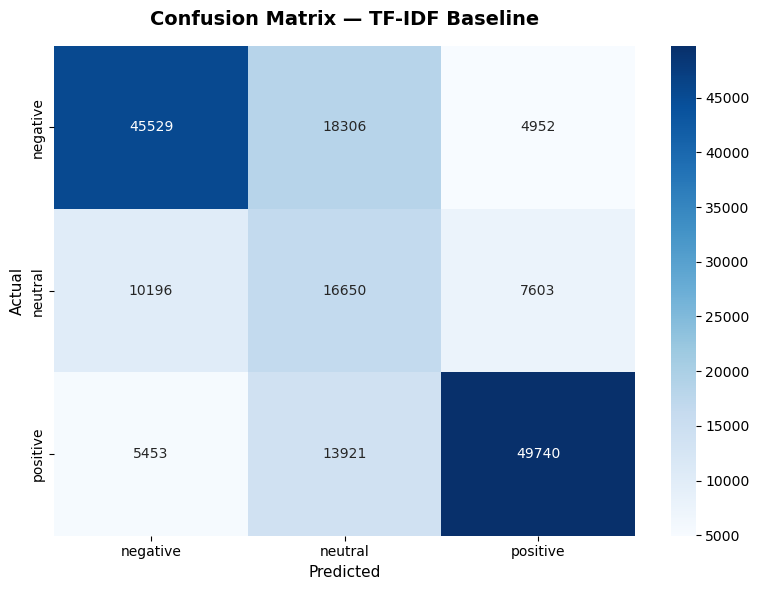

  Confusion matrix saved to: /Users/davidlupau/Documents/Filen/_IU/5th semester/30. Artificial Intelligence Project/sentiment-analysis-customer-reviews/analysis_output/TF-IDF_Baseline_confusion_matrix.png
Evaluating DistilBERT Champion

  DistilBERT Champion
  Accuracy : 0.7121
  Macro-F1 : 0.6864  ← primary metric

              precision    recall  f1-score   support

    negative     0.8335    0.6779    0.7477     68787
     neutral     0.3893    0.6061    0.4741     34449
    positive     0.8796    0.7989    0.8373     69114

    accuracy                         0.7121    172350
   macro avg     0.7008    0.6943    0.6864    172350
weighted avg     0.7632    0.7121    0.7289    172350

Plotting confusion matrix — DistilBERT Champion


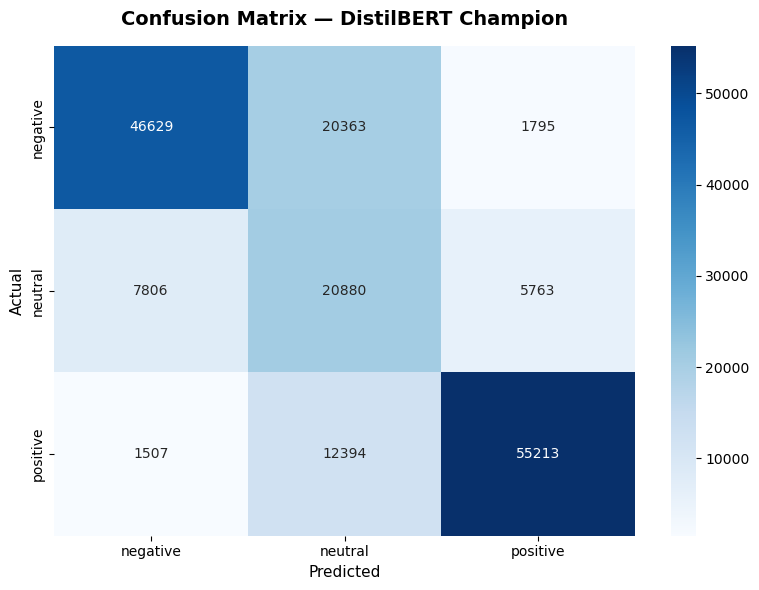

  Confusion matrix saved to: /Users/davidlupau/Documents/Filen/_IU/5th semester/30. Artificial Intelligence Project/sentiment-analysis-customer-reviews/analysis_output/DistilBERT_Champion_confusion_matrix.png

════════════════════════════════════════
MODEL COMPARISON SUMMARY
════════════════════════════════════════
                  Accuracy  Macro-F1
TF-IDF Baseline :  0.6494    0.6191
DistilBERT      :  0.7121    0.6864
════════════════════════════════════════


In [17]:
y_true = df_test["sentiment"].tolist()

metrics_baseline = evaluate_model(y_true, baseline_preds, "TF-IDF Baseline")
plot_confusion_matrix(y_true, baseline_preds, "TF-IDF Baseline")

metrics_distilbert = evaluate_model(y_true, distilbert_preds, "DistilBERT Champion")
plot_confusion_matrix(y_true, distilbert_preds, "DistilBERT Champion")

sep = "═" * 40
print(f"\n{sep}\nMODEL COMPARISON SUMMARY\n{sep}")
print(f"{'':16}  Accuracy  Macro-F1")
if metrics_baseline:
    print(f"{'TF-IDF Baseline':<16}:  {metrics_baseline['accuracy']:.4f}    {metrics_baseline['macro_f1']:.4f}")
if metrics_distilbert:
    print(f"{'DistilBERT':<16}:  {metrics_distilbert['accuracy']:.4f}    {metrics_distilbert['macro_f1']:.4f}")
print(sep)

---

### Probe set — qualitative evaluation

Aggregate F1 scores and confusion matrices tell you *how much* a model fails; they don't show *where* or *why*. A probe set of hand-crafted examples targeting specific linguistic phenomena fills that gap.

**Why a probe set?** The test set is drawn from the same distribution as training data, so a model can score well overall while remaining structurally blind to certain constructions. The probe set surfaces those blind spots by targeting:

- **Sarcasm** — surface sentiment (positive words) contradicts the intended meaning; TF-IDF has no mechanism to detect this because bag-of-words discards order and context.
- **Negation** — a single word (*not*, *never*, *can't*) flips the polarity of everything around it; TF-IDF counts the negation word as a feature but cannot propagate its scope.
- **Multipolarity** — a review contains both positive and negative spans; the correct label depends on their relative weight, which requires reading the whole sentence.
- **Control** — straightforward examples with no linguistic traps, used to confirm both models are functioning correctly.

DistilBERT's attention layers can, in principle, resolve all three hard phenomena by learning long-range dependencies. The probe set scores make that comparison concrete and case-by-case visible.

In [18]:
def evaluate_probe_set(vectorizer, baseline_model, distilbert_model, tokenizer, device):
    """Run both models on the probe set and print a per-phenomenon breakdown.

    Parameters:
        vectorizer (TfidfVectorizer): Fitted TF-IDF vectorizer.
        baseline_model (LogisticRegression): Fitted baseline classifier.
        distilbert_model: Fine-tuned DistilBERT model.
        tokenizer: DistilBERT tokenizer.
        device (torch.device): Compute device.

    Returns:
        pd.DataFrame | None: Results table with predictions and correctness
            flags, or None on error.
    """
    print("Running probe set evaluation")
    try:
        probe_path = PROJECT_ROOT / "data" / "probe_set.csv"
        df = pd.read_csv(probe_path)
        texts = df["text"].tolist()

        df["baseline_pred"] = predict_baseline(vectorizer, baseline_model, texts)
        df["distilbert_pred"] = predict_distilbert(
            distilbert_model, tokenizer, texts, device
        )
        df["baseline_correct"] = df["baseline_pred"] == df["true_label"]
        df["distilbert_correct"] = df["distilbert_pred"] == df["true_label"]

        results = df[[
            "id", "phenomenon", "text", "true_label",
            "baseline_pred", "distilbert_pred",
            "baseline_correct", "distilbert_correct",
        ]]

        # Per-phenomenon summary
        sep = "─" * 41
        print(f"\n{'Phenomenon':<14}  {'Baseline':<14}  DistilBERT")
        print(sep)
        for phenomenon, group in results.groupby("phenomenon"):
            n = len(group)
            b = int(group["baseline_correct"].sum())
            d = int(group["distilbert_correct"].sum())
            b_str = f"{b}/{n}  ({b / n * 100:.0f}%)"
            d_str = f"{d}/{n}  ({d / n * 100:.0f}%)"
            print(f"{phenomenon:<14}  {b_str:<14}  {d_str}")
        print(sep)
        n_total = len(results)
        b_total = int(results["baseline_correct"].sum())
        d_total = int(results["distilbert_correct"].sum())
        b_str = f"{b_total}/{n_total} ({b_total / n_total * 100:.0f}%)"
        d_str = f"{d_total}/{n_total} ({d_total / n_total * 100:.0f}%)"
        print(f"{'TOTAL':<14}  {b_str:<14}  {d_str}")

        # Per-row details
        print()
        for _, row in results.iterrows():
            b_mark = "✓" if row["baseline_correct"] else "✗"
            d_mark = "✓" if row["distilbert_correct"] else "✗"
            text_preview = str(row["text"])[:80]
            print(
                f"[{int(row['id']):>3}] {str(row['phenomenon']):<14} "
                f"true={row['true_label']:<10} "
                f"baseline={row['baseline_pred']:<10}{b_mark}  "
                f"distilbert={row['distilbert_pred']:<10}{d_mark}  "
                f'"{text_preview}"'
            )

        output_dir = PROJECT_ROOT / "analysis_output"
        output_dir.mkdir(exist_ok=True)
        output_path = output_dir / "probe_set_results.csv"
        results.to_csv(output_path, index=False)
        print(f"\n  Probe set results saved to: {output_path}")

        return results
    except Exception as e:
        print(f"  Error running probe set evaluation: {e}")
        return None

In [19]:
evaluate_probe_set(
    vectorizer_baseline,
    model_baseline,
    model_distilbert,
    tokenizer,
    DEVICE,
)

Running probe set evaluation

Phenomenon      Baseline        DistilBERT
─────────────────────────────────────────
control (negative)  1/1  (100%)     1/1  (100%)
control (positive)  3/3  (100%)     3/3  (100%)
multipolar      2/5  (40%)      2/5  (40%)
negation        3/5  (60%)      3/5  (60%)
sarcasm         5/6  (83%)      1/6  (17%)
─────────────────────────────────────────
TOTAL           14/20 (70%)     10/20 (50%)

[  1] negation       true=negative   baseline=positive  ✗  distilbert=positive  ✗  "I thought I would be satisfied ordering a product from this brand"
[  2] multipolar     true=neutral    baseline=positive  ✗  distilbert=positive  ✗  "Very happy with this t-shirt however the delivery was too slow"
[  3] negation       true=negative   baseline=negative  ✓  distilbert=negative  ✓  "You can't advertise a product as "one size fits all" when it is so small"
[  4] control (positive) true=positive   baseline=positive  ✓  distilbert=positive  ✓  "Probably the best trousers I

,id,phenomenon,text,true_label,baseline_pred,distilbert_pred,baseline_correct,distilbert_correct
0,1,negation,I thought I would be satisfied ordering a prod...,negative,positive,positive,False,False
1,2,multipolar,Very happy with this t-shirt however the deliv...,neutral,positive,positive,False,False
2,3,negation,"You can't advertise a product as ""one size fit...",negative,negative,negative,True,True
3,4,control (positive),Probably the best trousers I have ever bought....,positive,positive,positive,True,True
4,5,multipolar,The product is clearly not the same as on the ...,negative,negative,negative,True,True
5,6,multipolar,I think it would be useful to specify that the...,neutral,positive,positive,False,False
6,7,control (positive),I love the color on this dress. Very original.,positive,positive,positive,True,True
7,8,sarcasm,Oh great! Another brand that claims to be envi...,negative,positive,positive,False,False
8,9,negation,I was so excited when I ordered this hat. What...,negative,negative,negative,True,True
9,10,sarcasm,"Oh great, another item that fell apart after o...",negative,negative,positive,True,False


---

### Gradio interface

The Gradio interface is designed for non-technical end users — the marketing team who commissioned the tool. The interface abstracts away all model complexity and returns a simple sentiment label from DistilBERT, with no reference to training, evaluation, or model internals. This is the final deliverable that makes the system usable outside a data science context.

In [20]:
def predict(text, distilbert_model, tokenizer, device):
    """Run DistilBERT inference on a single review string.

    Parameters:
        text (str): A single customer review to classify.
        distilbert_model (DistilBertForSequenceClassification): Fine-tuned model.
        tokenizer (DistilBertTokenizerFast): Tokenizer matched to the model.
        device (torch.device): Compute device to run inference on.

    Returns:
        str | None: Predicted label ('positive', 'neutral', or 'negative'),
            or None if an error occurs.
    """
    try:
        return predict_distilbert(distilbert_model, tokenizer, [text], device)[0]
    except Exception as e:
        print(f"Error during prediction: {e}")
        return None


def load_models():
    """Load the fine-tuned DistilBERT model and tokenizer from disk.

    Returns:
        tuple[DistilBertForSequenceClassification, DistilBertTokenizerFast, torch.device]:
            Loaded model, tokenizer, and active compute device,
            or None if loading fails.
    """
    print("Loading models for Gradio interface...")
    try:
        device = detect_device()
        distilbert_model, tokenizer = load_distilbert(MODEL_SAVE_DIR, device)
        return distilbert_model, tokenizer, device
    except Exception as e:
        print(f"Error loading models: {e}")
        return None


def build_interface(distilbert_model, tokenizer, device):
    """Build and return the Gradio sentiment analysis interface.

    Parameters:
        distilbert_model (DistilBertForSequenceClassification): Fine-tuned model.
        tokenizer (DistilBertTokenizerFast): Tokenizer matched to the model.
        device (torch.device): Compute device to run inference on.

    Returns:
        gr.Interface: Configured Gradio interface ready to launch.
    """
    _LABEL_MAP = {
        "positive": "😊 Positive",
        "neutral":  "😐 Neutral",
        "negative": "😞 Negative",
    }

    def classify(text):
        label = predict(text, distilbert_model, tokenizer, device)
        return _LABEL_MAP.get(label, "Unable to classify — please try again.")

    return gr.Interface(
        fn=classify,
        inputs=gr.Textbox(
            label="Customer review",
            placeholder="Paste a customer review here...",
            lines=4,
        ),
        outputs=gr.Textbox(label="Sentiment"),
        title="Customer Review Sentiment Analyser",
        description=(
            "Paste any Amazon Fashion customer review to instantly detect "
            "whether the sentiment is positive, neutral, or negative."
        ),
        examples=[
            [
                "I absolutely love these jeans! The fit is perfect and the denim quality "
                "is outstanding. They arrived quickly and looked even better than the photos. "
                "I've already ordered two more pairs in different colours."
            ],
            [
                "These shoes fell apart after just three weeks of normal wear. The sole "
                "started peeling away and the stitching came undone on both sides. I followed "
                "the care instructions exactly and still had this problem — very disappointing "
                "for the price."
            ],
            [
                "The jacket is okay. The colour matches the listing and the sizing is accurate, "
                "but the material feels a bit thin for the price point. It does what it says — "
                "nothing more, nothing less."
            ],
        ],
        flagging_mode="never",
    )

In [21]:
iface = build_interface(*load_models())
iface.launch(share=True)

Loading models for Gradio interface...
Loading DistilBERT model from: saved_model


Loading weights: 100%|██████████████████████| 104/104 [00:00<00:00, 5008.35it/s]


  Model is on device: mps:0

* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
